## MSc Artificial Intelligence - Masters Project

## Farah Iqbal - S08431208

# MRI Feature Extraction

### Research Objective

The purpose of this notebook is to extract quantitative MRI-derived biomarkers from Multiple Sclerosis brain scans for use within the proposed multimodal AI framework.

Lesion segmentation masks will be analysed to generate imaging features including lesion volume, lesion count and lesion size measurements. These MRI-derived biomarkers will later be combined with the cleaned clinical dataset produced in Notebook 1 to create a multimodal dataset for disability severity prediction.

The extracted imaging features will also support the explainability component of the project, where an Agentic AI framework will generate evidence-based explanations for model predictions and compare them with traditional explainability methods including SHAP and LIME.

## Notebook 2 Structure

- Load the MRI dataset from Google Drive
- Explore the MRI dataset structure
- Load and visualise FLAIR MRI scans
- Display lesion segmentation masks
- Overlay lesion masks onto MRI scans
- Extract MRI-derived biomarkers
  - Lesion volume
  - Lesion count
  - Average lesion size
  - Largest lesion size
  - Lesion size categories
- Extract features for all patients
- Explore the extracted MRI features
- Generate summary statistics
- Create visualisations and charts
- Export the MRI feature dataset for multimodal modelling


Install Libraries

In [ ]:
# Install required medical imaging libraries
!pip install nibabel scipy scikit-image -q

Import Libraries

In [ ]:
# Import core libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

# For counting separate lesion regions
from scipy.ndimage import label

# Display all dataframe columns
pd.set_option("display.max_columns", None)

Mount Google Drive

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Set Dataset Path

In [ ]:
# Path to the main MRI dataset folder in Google Drive

dataset_path = "/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information"

# Check that the folder exists
print("Dataset path exists:", os.path.exists(dataset_path))

Dataset path exists: True


Check Patient Folders

In [ ]:
# Find all patient folders
patient_folders = sorted(
    glob.glob(os.path.join(dataset_path, "Patient-*")),
    key=lambda x: int(os.path.basename(x).split("-")[-1])
)

# Display number of folders found
print("Number of patient folders found:", len(patient_folders))

# Show first few folders
patient_folders[:5]

Number of patient folders found: 60


['/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-1',
 '/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-2',
 '/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-3',
 '/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-4',
 '/content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-5']

## Visualising One Patient Scan

Before extracting features from all patients, one example patient is loaded and visualised. This helps confirm that the MRI scan and lesion segmentation mask are loading correctly.

Patient 1 FLAIR and Lesion Mask

In [ ]:
# Select patient 1 as an example
example_patient = patient_folders[0]

# Get patient ID from folder name
patient_id = int(os.path.basename(example_patient).split("-")[-1])

# Define file paths
flair_path = os.path.join(example_patient, f"{patient_id}-Flair.nii")
mask_path = os.path.join(example_patient, f"{patient_id}-LesionSeg-Flair.nii")

print("FLAIR path:", flair_path)
print("Mask path:", mask_path)

# Load MRI and lesion mask
flair_img = nib.load(flair_path)
mask_img = nib.load(mask_path)

# Convert to numpy arrays
flair_data = flair_img.get_fdata()
mask_data = mask_img.get_fdata()

print("FLAIR shape:", flair_data.shape)
print("Mask shape:", mask_data.shape)
print("Voxel spacing:", flair_img.header.get_zooms())

FLAIR path: /content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-1/1-Flair.nii
Mask path: /content/drive/MyDrive/Brain MRI Dataset of Multiple Sclerosis with Consensus Manual Lesion Segmentation and Patient Meta Information/Patient-1/1-LesionSeg-Flair.nii
FLAIR shape: (256, 256, 23)
Mask shape: (256, 256, 23)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


Visualise FLAIR Scan

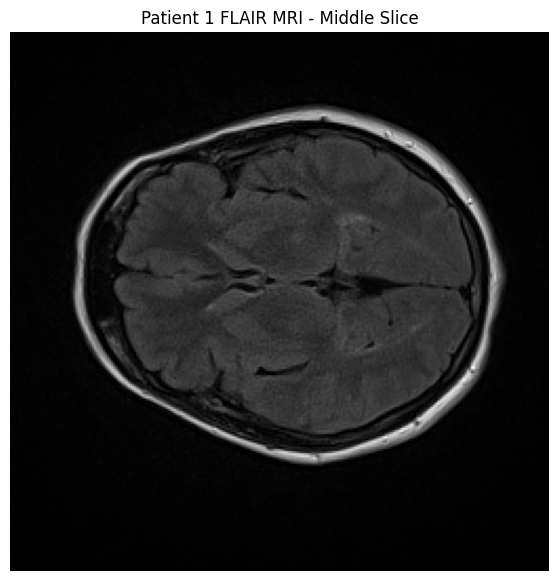

In [ ]:
# Select middle slice for visualisation
middle_slice = flair_data.shape[2] // 2

plt.figure(figsize=(7, 7))
plt.imshow(flair_data[:, :, middle_slice].T, cmap="gray", origin="lower")
plt.title(f"Patient {patient_id} FLAIR MRI - Middle Slice")
plt.axis("off")
plt.show()

Visualise Lesion Mask

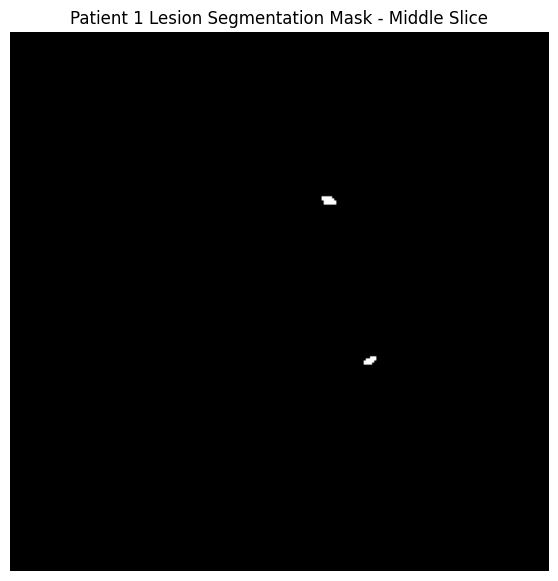

In [ ]:
plt.figure(figsize=(7, 7))
plt.imshow(mask_data[:, :, middle_slice].T, cmap="gray", origin="lower")
plt.title(f"Patient {patient_id} Lesion Segmentation Mask - Middle Slice")
plt.axis("off")
plt.show()

Overlay Lesion Mask on MRI

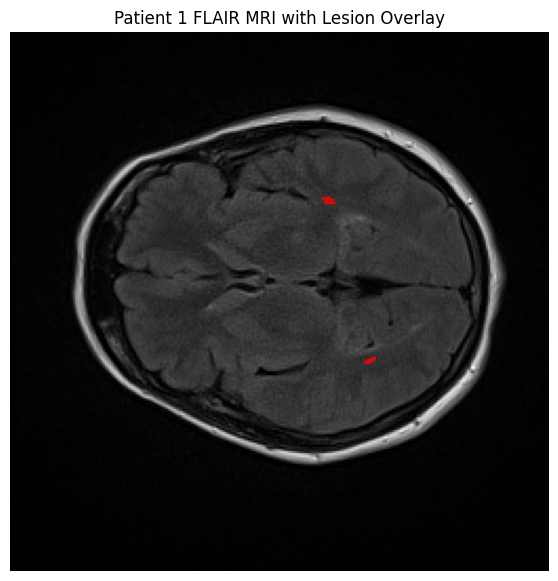

In [ ]:
plt.figure(figsize=(7, 7))

# Display MRI scan
plt.imshow(flair_data[:, :, middle_slice].T, cmap="gray", origin="lower")

# Overlay lesion mask
plt.imshow(
    np.ma.masked_where(mask_data[:, :, middle_slice].T == 0, mask_data[:, :, middle_slice].T),
    cmap="autumn",
    alpha=0.7,
    origin="lower"
)

plt.title(f"Patient {patient_id} FLAIR MRI with Lesion Overlay")
plt.axis("off")
plt.show()

## Extracting MRI-Derived Biomarkers

The lesion segmentation mask is used to extract numerical imaging features. These include:

- Total lesion volume
- Number of separate lesions
- Average lesion size
- Largest lesion size
- Small, medium and large lesion counts

These features are extracted mainly from the FLAIR lesion segmentation mask because FLAIR is highly useful for visualising MS white matter lesions.

Create Feature Extraction Function

In [ ]:
def extract_lesion_features(mask_path):
    # Extract lesion features from a binary lesion segmentation mask

    # Load mask image
    mask_img = nib.load(mask_path)
    mask_data = mask_img.get_fdata()

    # Convert mask to binary
    binary_mask = mask_data > 0

    # Get voxel dimensions from NIfTI header
    voxel_dims = mask_img.header.get_zooms()[:3]
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]

    # Total lesion voxels
    lesion_voxels = np.sum(binary_mask)

    # Total lesion volume in mm³
    lesion_volume_mm3 = lesion_voxels * voxel_volume

    # Connected component analysis to count separate lesions
    labelled_mask, lesion_count = label(binary_mask)

    # Calculate size of each lesion
    lesion_sizes = []

    for lesion_label in range(1, lesion_count + 1):
        size = np.sum(labelled_mask == lesion_label)
        lesion_sizes.append(size)

    # If no lesions exist, return zero values
    if len(lesion_sizes) == 0:
        avg_lesion_size = 0
        largest_lesion_size = 0
        smallest_lesion_size = 0
        small_lesions = 0
        medium_lesions = 0
        large_lesions = 0
    else:
        lesion_sizes = np.array(lesion_sizes)

        avg_lesion_size = np.mean(lesion_sizes)
        largest_lesion_size = np.max(lesion_sizes)
        smallest_lesion_size = np.min(lesion_sizes)

        # Simple lesion size categories based on voxel count
        small_lesions = np.sum(lesion_sizes < 10)
        medium_lesions = np.sum((lesion_sizes >= 10) & (lesion_sizes < 50))
        large_lesions = np.sum(lesion_sizes >= 50)

    return {
        "Lesion_Voxels": lesion_voxels,
        "Lesion_Volume_mm3": lesion_volume_mm3,
        "Lesion_Count": lesion_count,
        "Average_Lesion_Size": avg_lesion_size,
        "Largest_Lesion_Size": largest_lesion_size,
        "Smallest_Lesion_Size": smallest_lesion_size,
        "Small_Lesions": small_lesions,
        "Medium_Lesions": medium_lesions,
        "Large_Lesions": large_lesions
    }

Test Function on Patient 1

In [ ]:
# Test the function on Patient 1 FLAIR lesion mask
patient_1_features = extract_lesion_features(mask_path)

patient_1_features

{'Lesion_Voxels': np.int64(776),
 'Lesion_Volume_mm3': np.float64(776.0),
 'Lesion_Count': 52,
 'Average_Lesion_Size': np.float64(14.923076923076923),
 'Largest_Lesion_Size': np.int64(68),
 'Smallest_Lesion_Size': np.int64(2),
 'Small_Lesions': np.int64(25),
 'Medium_Lesions': np.int64(26),
 'Large_Lesions': np.int64(1)}

## Extracting MRI Features for All Patients

The feature extraction function is now applied to every patient folder. The main extracted features will be stored in a dataframe and exported as a CSV file for use in the next notebook.

Extract FLAIR Features for All Patients

In [ ]:
# Create empty list to store results
mri_features = []

# Loop through each patient folder
for folder in patient_folders:

    # Extract patient ID
    patient_id = int(os.path.basename(folder).split("-")[-1])

    # Build expected FLAIR lesion mask path
    flair_mask_path = os.path.join(folder, f"{patient_id}-LesionSeg-Flair.nii")

    # Check if file exists
    if os.path.exists(flair_mask_path):

        # Extract lesion features
        features = extract_lesion_features(flair_mask_path)

        # Add patient ID
        features["Patient_ID"] = patient_id

        # Add results to list
        mri_features.append(features)

    else:
        print(f"Missing FLAIR lesion mask for Patient {patient_id}")

# Convert to dataframe
mri_df = pd.DataFrame(mri_features)

# Move Patient_ID to first column
cols = ["Patient_ID"] + [col for col in mri_df.columns if col != "Patient_ID"]
mri_df = mri_df[cols]

# Display first rows
mri_df.head()

,Patient_ID,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
0,1,776,776.0,52,14.923077,68,2,25,26,1
1,2,2485,2485.0,33,75.303030,629,6,4,20,9
2,3,2273,2273.0,65,34.969231,188,1,14,35,16
3,4,4906,4906.0,21,233.619048,2194,3,6,9,6
4,5,2109,2109.0,59,35.745763,257,5,9,39,11


Check MRI Feature Dataset

In [ ]:
# Check shape of MRI feature dataset
print("MRI feature dataset shape:", mri_df.shape)

# Check missing values
mri_df.isnull().sum()

MRI feature dataset shape: (60, 10)


,0
Patient_ID,0
Lesion_Voxels,0
Lesion_Volume_mm3,0
Lesion_Count,0
Average_Lesion_Size,0
Largest_Lesion_Size,0
Smallest_Lesion_Size,0
Small_Lesions,0
Medium_Lesions,0
Large_Lesions,0


Summary Statistics

In [ ]:
# Display summary statistics
mri_df.describe()

,Patient_ID,Lesion_Voxels,Lesion_Volume_mm3,Lesion_Count,Average_Lesion_Size,Largest_Lesion_Size,Smallest_Lesion_Size,Small_Lesions,Medium_Lesions,Large_Lesions
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,8086.083333,8086.083333,44.233333,206.022490,2455.15000,5.083333,9.916667,17.783333,16.533333
std,17.464249,12724.711405,12724.711405,41.387940,306.784186,5080.93112,13.754866,24.041836,17.936887,16.868853
min,1.000000,324.000000,324.000000,2.000000,7.653509,47.00000,1.000000,0.000000,0.000000,0.000000
25%,15.750000,1741.250000,1741.250000,21.750000,49.717672,307.50000,1.000000,2.000000,7.750000,7.000000
50%,30.500000,3300.500000,3300.500000,32.500000,100.423828,625.00000,2.000000,4.500000,14.000000,12.000000
75%,45.250000,7703.250000,7703.250000,51.250000,240.754831,1972.00000,4.000000,8.000000,20.250000,17.250000
max,60.000000,60999.000000,60999.000000,228.000000,1783.259259,29363.00000,104.000000,178.000000,111.000000,101.000000


## Visualising MRI-Derived Features

The following charts help explore lesion volume, lesion count and lesion size distribution across patients.

Histogram of Lesion Volume

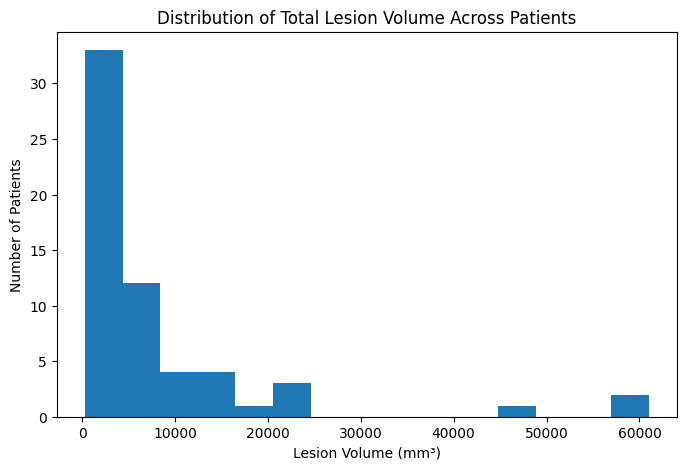

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(mri_df["Lesion_Volume_mm3"], bins=15)
plt.xlabel("Lesion Volume (mm³)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Total Lesion Volume Across Patients")
plt.show()

Histogram of Lesion Count

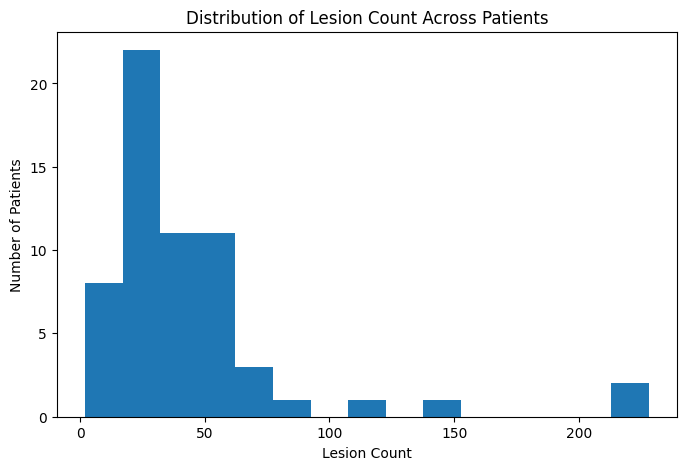

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(mri_df["Lesion_Count"], bins=15)
plt.xlabel("Lesion Count")
plt.ylabel("Number of Patients")
plt.title("Distribution of Lesion Count Across Patients")
plt.show()

Scatter Plot - Lesion Count vs Lesion Volume

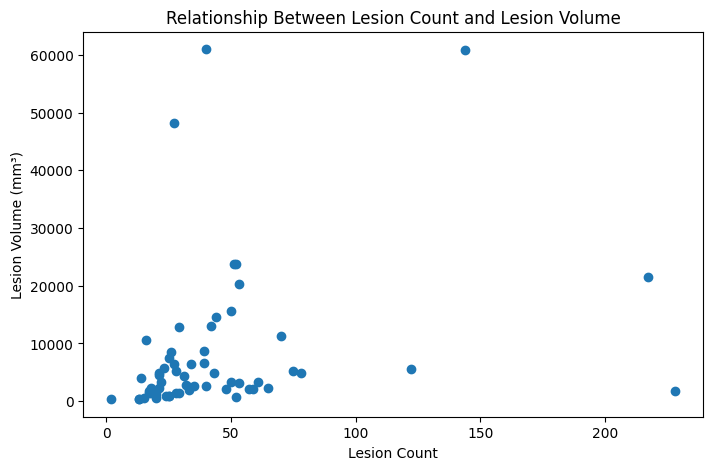

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(mri_df["Lesion_Count"], mri_df["Lesion_Volume_mm3"])
plt.xlabel("Lesion Count")
plt.ylabel("Lesion Volume (mm³)")
plt.title("Relationship Between Lesion Count and Lesion Volume")
plt.show()

Boxplot of Main MRI Features

/tmp/ipykernel_1122/437933142.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(main_features.values, labels=main_features.columns)


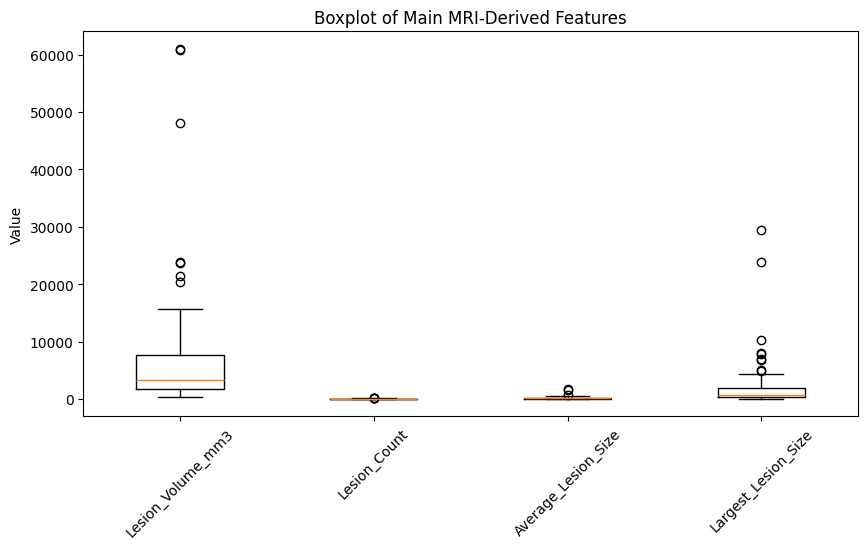

In [ ]:
# Select main MRI features
main_features = mri_df[
    [
        "Lesion_Volume_mm3",
        "Lesion_Count",
        "Average_Lesion_Size",
        "Largest_Lesion_Size"
    ]
]

plt.figure(figsize=(10, 5))
plt.boxplot(main_features.values, labels=main_features.columns)
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.title("Boxplot of Main MRI-Derived Features")
plt.show()

Show lesion size distribution

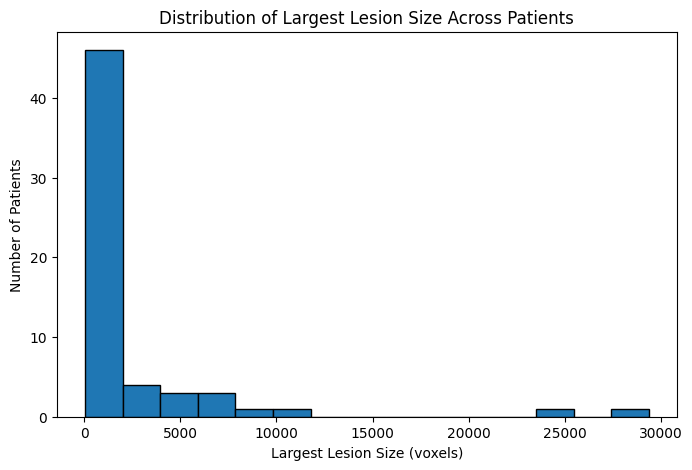

In [ ]:
# Plot the distribution of the largest lesion size across patients

plt.figure(figsize=(8, 5))

plt.hist(
    mri_df["Largest_Lesion_Size"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Largest Lesion Size (voxels)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Largest Lesion Size Across Patients")

plt.show()

Top 10 Patients by Lesion Volume

In [ ]:
# Sort patients by lesion volume
top_lesion_volume = mri_df.sort_values(
    by="Lesion_Volume_mm3",
    ascending=False
).head(10)

top_lesion_volume[["Patient_ID", "Lesion_Volume_mm3", "Lesion_Count", "Largest_Lesion_Size"]]

,Patient_ID,Lesion_Volume_mm3,Lesion_Count,Largest_Lesion_Size
30,31,60999.0,40,29363
39,40,60863.0,144,10275
57,58,48148.0,27,23929
44,45,23795.0,52,6928
34,35,23735.0,51,7957
37,38,21501.0,217,7856
51,52,20338.0,53,2202
55,56,15630.0,50,2034
29,30,14537.0,44,6824
47,48,13086.0,42,4344


Bar Chart - Top 10 Lesion Volumes

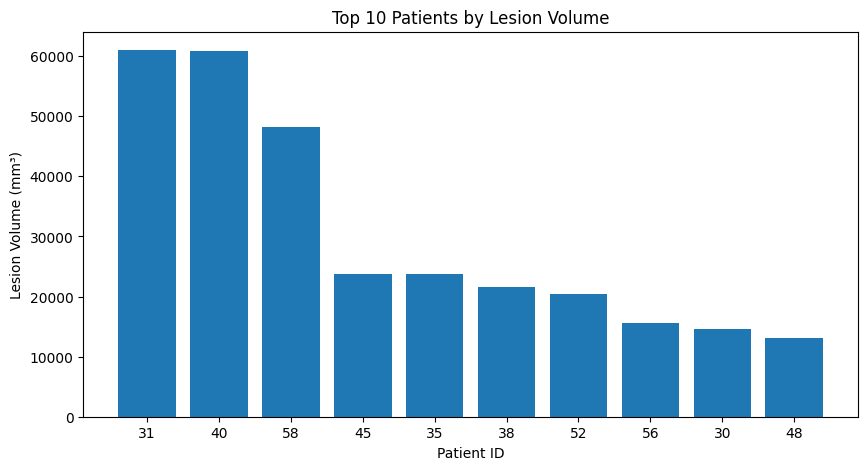

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    top_lesion_volume["Patient_ID"].astype(str),
    top_lesion_volume["Lesion_Volume_mm3"]
)
plt.xlabel("Patient ID")
plt.ylabel("Lesion Volume (mm³)")
plt.title("Top 10 Patients by Lesion Volume")
plt.show()

Lesion Size Category Totals

In [ ]:
# Calculate total number of small, medium and large lesions across all patients
lesion_category_totals = pd.DataFrame({
    "Lesion_Size_Category": ["Small Lesions", "Medium Lesions", "Large Lesions"],
    "Count": [
        mri_df["Small_Lesions"].sum(),
        mri_df["Medium_Lesions"].sum(),
        mri_df["Large_Lesions"].sum()
    ]
})

lesion_category_totals

,Lesion_Size_Category,Count
0,Small Lesions,595
1,Medium Lesions,1067
2,Large Lesions,992


Bar Chart of Lesion Size Categories

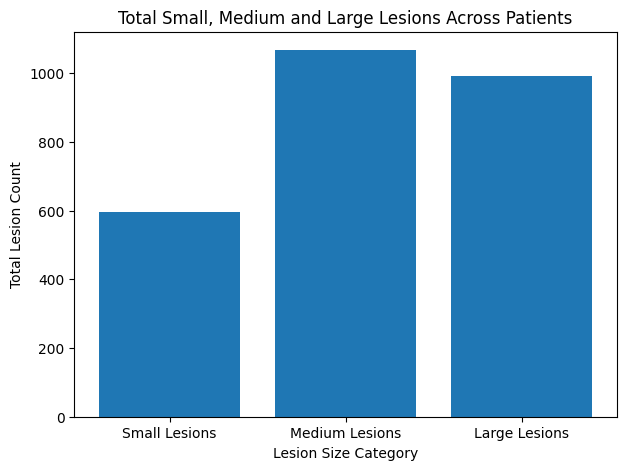

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    lesion_category_totals["Lesion_Size_Category"],
    lesion_category_totals["Count"]
)
plt.xlabel("Lesion Size Category")
plt.ylabel("Total Lesion Count")
plt.title("Total Small, Medium and Large Lesions Across Patients")
plt.show()

## Comparison Across MRI Modalities

The dataset contains lesion segmentation masks for FLAIR, T1 and T2 images. Although FLAIR will be used as the main modality, extracting T1 and T2 lesion features can provide additional comparison features for the multimodal dataset.

Extract FLAIR, T1 and T2 Features

In [ ]:
# Create empty list for modality comparison features
modality_features = []

modalities = {
    "FLAIR": "LesionSeg-Flair",
    "T1": "LesionSeg-T1",
    "T2": "LesionSeg-T2"
}

for folder in patient_folders:

    patient_id = int(os.path.basename(folder).split("-")[-1])

    patient_features = {"Patient_ID": patient_id}

    for modality_name, file_label in modalities.items():

        mask_path = os.path.join(folder, f"{patient_id}-{file_label}.nii")

        if os.path.exists(mask_path):

            features = extract_lesion_features(mask_path)

            patient_features[f"{modality_name}_Lesion_Volume_mm3"] = features["Lesion_Volume_mm3"]
            patient_features[f"{modality_name}_Lesion_Count"] = features["Lesion_Count"]
            patient_features[f"{modality_name}_Average_Lesion_Size"] = features["Average_Lesion_Size"]
            patient_features[f"{modality_name}_Largest_Lesion_Size"] = features["Largest_Lesion_Size"]

        else:
            patient_features[f"{modality_name}_Lesion_Volume_mm3"] = np.nan
            patient_features[f"{modality_name}_Lesion_Count"] = np.nan
            patient_features[f"{modality_name}_Average_Lesion_Size"] = np.nan
            patient_features[f"{modality_name}_Largest_Lesion_Size"] = np.nan

    modality_features.append(patient_features)

modality_df = pd.DataFrame(modality_features)

modality_df.head()

,Patient_ID,FLAIR_Lesion_Volume_mm3,FLAIR_Lesion_Count,FLAIR_Average_Lesion_Size,FLAIR_Largest_Lesion_Size,T1_Lesion_Volume_mm3,T1_Lesion_Count,T1_Average_Lesion_Size,T1_Largest_Lesion_Size,T2_Lesion_Volume_mm3,T2_Lesion_Count,T2_Average_Lesion_Size,T2_Largest_Lesion_Size
0,1,776.0,52,14.923077,68,416.0,8,52.000000,102,481.0,37,13.000000,75
1,2,2485.0,33,75.303030,629,3666.0,12,305.500000,1159,4617.0,31,148.935484,1096
2,3,2273.0,65,34.969231,188,622.0,9,69.111111,117,4263.0,51,83.588235,535
3,4,4906.0,21,233.619048,2194,4212.0,34,123.882353,575,2560.0,30,85.333333,565
4,5,2109.0,59,35.745763,257,1053.0,7,150.428571,490,1850.0,54,34.259259,277


Compare Average Lesion Volume by Modality

In [ ]:
# Calculate average lesion volume for each modality
modality_volume_summary = pd.DataFrame({
    "Modality": ["FLAIR", "T1", "T2"],
    "Average_Lesion_Volume_mm3": [
        modality_df["FLAIR_Lesion_Volume_mm3"].mean(),
        modality_df["T1_Lesion_Volume_mm3"].mean(),
        modality_df["T2_Lesion_Volume_mm3"].mean()
    ]
})

modality_volume_summary

,Modality,Average_Lesion_Volume_mm3
0,FLAIR,8086.083333
1,T1,2729.783333
2,T2,6394.666667


Bar Chart - Average Lesion Volume by Modality

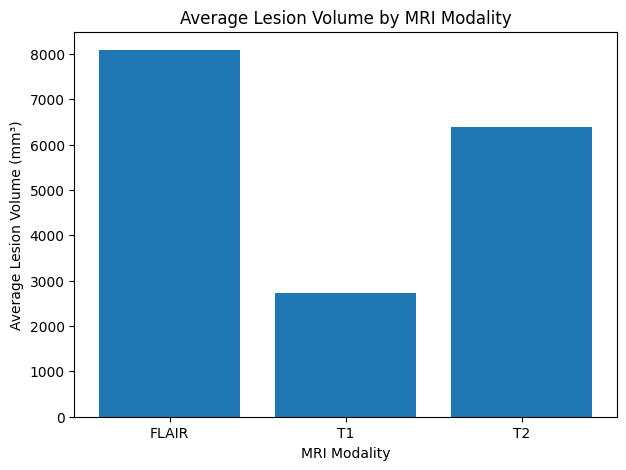

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    modality_volume_summary["Modality"],
    modality_volume_summary["Average_Lesion_Volume_mm3"]
)
plt.xlabel("MRI Modality")
plt.ylabel("Average Lesion Volume (mm³)")
plt.title("Average Lesion Volume by MRI Modality")
plt.show()

Compare Average Lesion Count by Modality

In [ ]:
modality_count_summary = pd.DataFrame({
    "Modality": ["FLAIR", "T1", "T2"],
    "Average_Lesion_Count": [
        modality_df["FLAIR_Lesion_Count"].mean(),
        modality_df["T1_Lesion_Count"].mean(),
        modality_df["T2_Lesion_Count"].mean()
    ]
})

modality_count_summary

,Modality,Average_Lesion_Count
0,FLAIR,44.233333
1,T1,13.066667
2,T2,33.500000


Bar Chart - Average Lesion Count by Modality

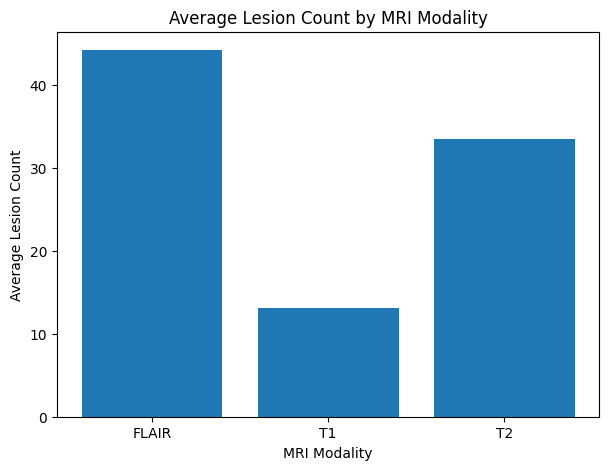

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(
    modality_count_summary["Modality"],
    modality_count_summary["Average_Lesion_Count"]
)
plt.xlabel("MRI Modality")
plt.ylabel("Average Lesion Count")
plt.title("Average Lesion Count by MRI Modality")
plt.show()

## Export MRI Features

The extracted MRI features are exported as CSV files. These files will be used in the next notebook, where the MRI-derived biomarkers will be merged with the cleaned clinical dataset from Notebook 1.

Create Output Folder

In [ ]:
# Define output folder
output_folder = "/content/drive/MyDrive/MS_Dissertation/Outputs"

# Create folder
os.makedirs(output_folder, exist_ok=True)

print("Output folder ready:", output_folder)

Output folder ready: /content/drive/MyDrive/MS_Dissertation/Outputs


Export Main FLAIR MRI Features

In [ ]:
# Save main FLAIR MRI features
mri_output_path = os.path.join(output_folder, "mri_features_flair.csv")

mri_df.to_csv(mri_output_path, index=False)

print("FLAIR MRI features saved to:")
print(mri_output_path)

FLAIR MRI features saved to:
/content/drive/MyDrive/MS_Dissertation/Outputs/mri_features_flair.csv


Export Multimodal MRI Comparison Features

In [ ]:
# Save FLAIR, T1 and T2 MRI comparison features
modality_output_path = os.path.join(output_folder, "mri_features_all_modalities.csv")

modality_df.to_csv(modality_output_path, index=False)

print("All modality MRI features saved to:")
print(modality_output_path)

All modality MRI features saved to:
/content/drive/MyDrive/MS_Dissertation/Outputs/mri_features_all_modalities.csv


In [ ]:
mri_df.to_excel(
    "mri_features.xlsx",
    index=False
)

Print Dataset Dimensions

In [ ]:
print("Rows:", mri_df.shape[0])
print("Columns:", mri_df.shape[1])

Rows: 60
Columns: 10


## Summary

This notebook extracted MRI-derived biomarkers from lesion segmentation masks for Multiple Sclerosis patients. The main features extracted from FLAIR lesion masks included lesion volume, lesion count, average lesion size and largest lesion size. Additional comparison features were also extracted from T1 and T2 lesion masks.

The output files from this notebook will be used in the next stage of the project to create a multimodal dataset by merging MRI-derived biomarkers with clinical variables from Notebook 1.

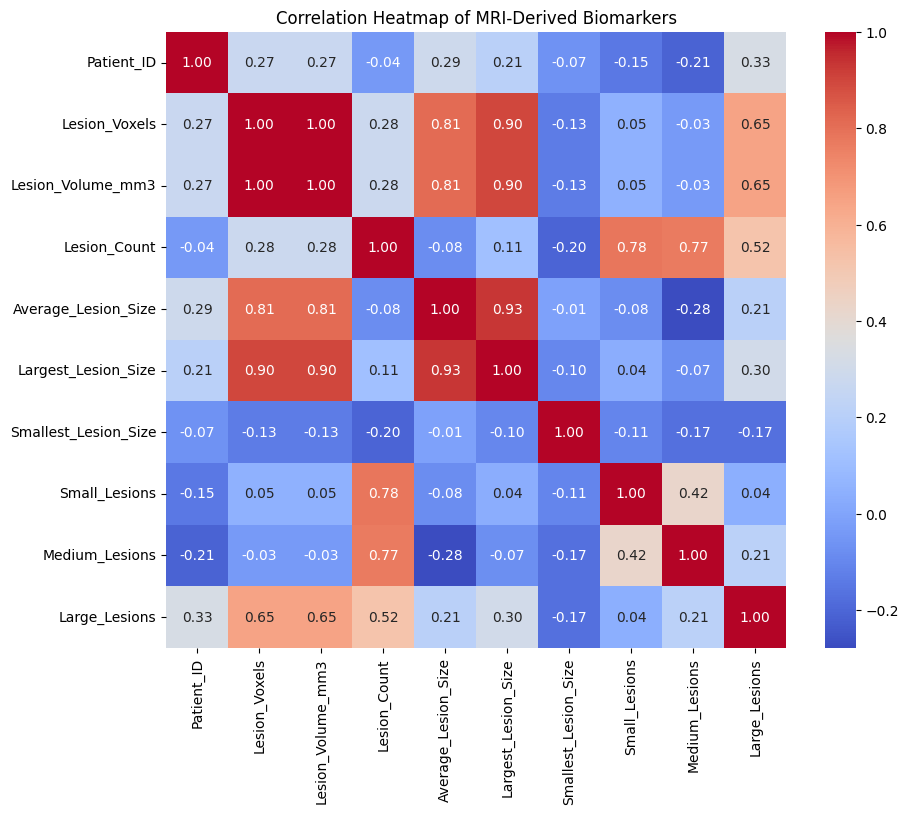

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    mri_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of MRI-Derived Biomarkers")

plt.show()